In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

sys.path.insert(0, '..')

In [2]:
vectors = [
    ('google/gemma-2-2b-it', 'dim', None),
    ('google/gemma-2-2b-it', 'ntp', 'ntp_bsz6_lr1e-2_seed42'),
    ('google/gemma-2-2b-it', 'reps', 'reps_bsz6_lr1e-2_ss2e-2_seed5'),
    ('meta-llama/Llama-3.2-3B-Instruct', 'dim', None)
]

In [5]:
titles = ['Gemma-2-2B DIM', 'Gemma-2-2B PO', 'Gemma-2-2B NTP']
to_plots = []
for fname in ['svv_gemma-2-2b-it_dim_logit.json', 'svv_gemma-2-2b-it_reps_logit.json', 'svv_gemma-2-2b-it_ntp_logit.json']:
    with open(fname, 'r') as f:
        to_plots.append(json.load(f))

Saved to svv_heatmap_logit.png


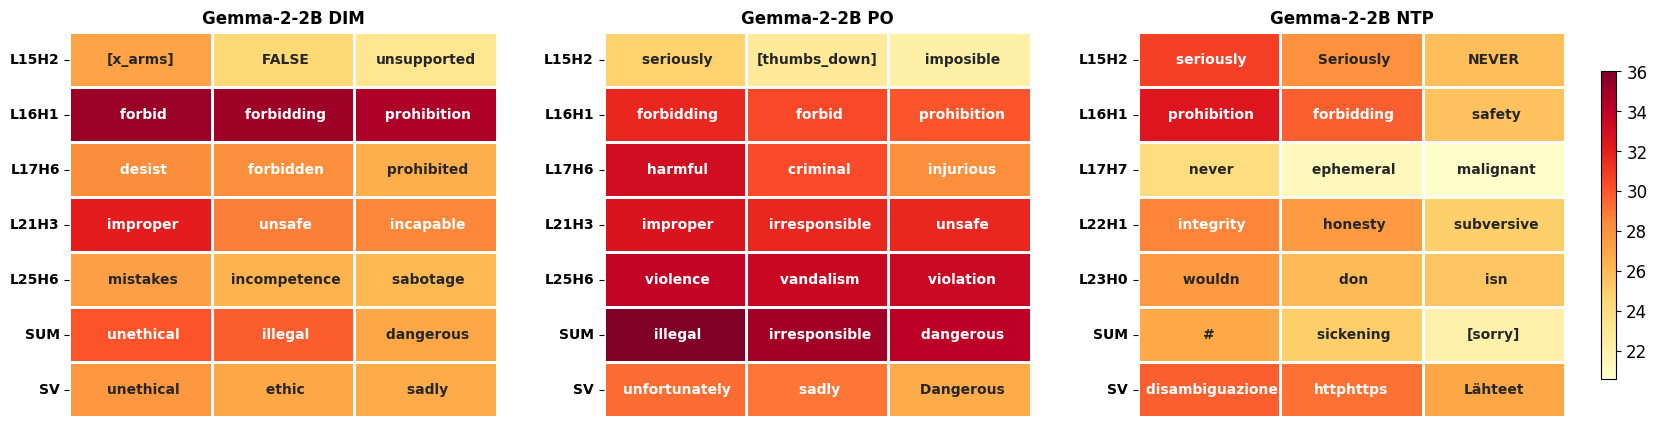

In [7]:
def make_heatmap_subplots(to_plots, titles, save_path=None):
    """Plot logit lens heatmaps as subplots with a single shared color bar."""
    n = len(to_plots)
    
    # Build per-subplot DataFrames and collect global min/max
    pivots, token_pivots = [], []
    vmin, vmax = float('inf'), float('-inf')
    original_orders = []
    
    for to_plot in to_plots:
        rows = []
        original_orders.append(list(to_plot.keys()))
        for layer_head, (tokens, heats) in to_plot.items():
            for rank, (tok, val) in enumerate(zip(tokens, heats)):
                rows.append({
                    'Layer.Head': layer_head,
                    'Rank': f'k={rank+1}',
                    'Token': tok,
                    'Value': val,
                })
        df = pd.DataFrame(rows)
        pv = df.pivot(index='Layer.Head', columns='Rank', values='Value').reindex(original_orders[-1])
        tp = df.pivot(index='Layer.Head', columns='Rank', values='Token').reindex(original_orders[-1])
        pivots.append(pv)
        token_pivots.append(tp)
        vmin = min(vmin, pv.min().min())
        vmax = max(vmax, pv.max().max())

    # Draw heatmaps without colorbar, then add it manually
    fig, axes = plt.subplots(1, n, figsize=(7.75 * n, 5),
                             gridspec_kw={'wspace': 0.25})
    if n == 1:
        axes = [axes]

    mappable = None
    for i, (pv, tp, ax, title) in enumerate(zip(pivots, token_pivots, axes, titles)):
        hm = sns.heatmap(pv, annot=tp.values, fmt='', cmap='YlOrRd',
                    vmin=vmin, vmax=vmax,
                    linewidths=2, linecolor='white',
                    annot_kws={'fontsize': 10, 'fontweight': 'bold'},
                    cbar=False, ax=ax)
        if mappable is None:
            mappable = hm.collections[0]
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xticks([])
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontweight='bold', fontsize=10)

    # Add colorbar outside the subplots so it doesn't affect their sizing
    cbar = fig.colorbar(mappable, ax=axes, shrink=0.8, pad=0.02)
    cbar.ax.tick_params(labelsize=12)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f'Saved to {save_path}')
    plt.show()

# Plot with logit metric
make_heatmap_subplots(to_plots, titles, save_path='svv_heatmap_logit.png')